# 01 · Exploración de los datos (reto Embat · HackSpain X-Ray)

Recorrido tabla a tabla por el dataset para entender **qué hay, cómo se relaciona y qué trampas tiene** antes de hacer feature engineering para el score de salud financiera.

**Requisitos:** CSV originales en `data/raw/` (en `.gitignore`). El notebook se puede ejecutar desde `notebooks/` o desde la raíz del repo. Tarda alrededor de un minuto, casi todo en cargar `transactions.csv`.

**Índice**
0. Mapa del dataset y carga
1. `groups`
2. `companies`
3. `banking_products`
4. `debt_products`
5. `debt_schedule_config`
6. `balances`
7. `transactions`
8. `invoices`
9. Cruces entre tablas: cobertura, contrapartes y reconstrucción de saldos
10. Conclusiones para el feature engineering

In [1]:
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "raw"          # CSV originales (ver docs/decisiones.md)
import sys
sys.path.insert(0, str(ROOT / "src"))
from xray.fx import FX_ASOF, FX_TO_EUR, to_eur   # tipos fijos a EUR (decisión D32)

assert DATA.exists(), f"No encuentro {DATA}: coloca los CSV originales en data/raw/"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Paleta categórica fija (siempre en este orden) y estilo sobrio
PAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, GRID, MUTED = "#0b0b0b", "#52514e", "#e6e5e1", "#b9b8b2"
plt.rcParams.update({
    "figure.figsize": (9, 4), "figure.dpi": 100,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": INK2,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "font.size": 10,
    "axes.prop_cycle": plt.cycler(color=PAL), "lines.linewidth": 2,
})

def hbar(s, title, xlabel="", color=PAL[0], fmt="{:,.0f}", ax=None):
    """Barras horizontales ordenadas, con el valor al final de cada barra."""
    s = s.sort_values()
    if ax is None:
        _, ax = plt.subplots(figsize=(9, max(2.5, 0.32 * len(s) + 1)))
    ax.barh(s.index.astype(str), s.values, color=color, height=0.7)
    ax.grid(axis="y", visible=False)
    for y, v in enumerate(s.values):
        ax.text(v, y, " " + fmt.format(v), va="center", fontsize=9, color=INK2)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.margins(x=0.12)
    return ax

def pct(x):
    return f"{100 * x:.1f}%"

## 0 · Mapa del dataset y carga

```
groups (250) 1─N companies (1,286) 1─N banking_products ─┐
                                   1─N debt_products ────┼─ balances (foto a 2026-09-01)
                                   │     └─ debt_schedule_config (solo préstamos con cuadro)
                                   1─N transactions  (movimientos bancarios, 24 meses)
                                   1─N invoices      (facturas del ERP)
```

`company_id` cruza todas las tablas y `product_id` une cada movimiento y cada saldo con su cuenta.

**Primera trampa:** `transactions.csv` contiene **bytes NUL**, retornos de carro sueltos y saltos de línea dentro de campos entrecomillados. El lector de `pyarrow` falla. Hay que quitar los NUL y usar el parser C de pandas, que es el que usa `load_transactions()`.

In [2]:
def load_transactions(path=DATA / "transactions.csv"):
    raw = path.read_bytes().replace(b"\x00", b"")          # quita los bytes NUL
    return pd.read_csv(io.BytesIO(raw), parse_dates=["date", "value_date"], low_memory=False)

groups    = pd.read_csv(DATA / "groups.csv")
companies = pd.read_csv(DATA / "companies.csv", parse_dates=["created_at"])
banking   = pd.read_csv(DATA / "banking_products.csv", parse_dates=["created_at"])
debt      = pd.read_csv(DATA / "debt_products.csv", parse_dates=["created_at"])
schedule  = pd.read_csv(DATA / "debt_schedule_config.csv", parse_dates=["next_payment_date", "last_payment_date"])
balances  = pd.read_csv(DATA / "balances.csv", parse_dates=["date"])
invoices  = pd.read_csv(DATA / "invoices.csv", parse_dates=["issuance_date", "due_date", "payment_date"], low_memory=False)
tx        = load_transactions()

TABLAS = dict(groups=groups, companies=companies, banking_products=banking, debt_products=debt,
              debt_schedule_config=schedule, balances=balances, invoices=invoices, transactions=tx)
comp2grp = companies.set_index("company_id").group_id

resumen = pd.DataFrame({
    "filas": {k: len(v) for k, v in TABLAS.items()},
    "columnas": {k: v.shape[1] for k, v in TABLAS.items()},
    "empresas": {k: v.company_id.nunique() for k, v in TABLAS.items() if "company_id" in v},
    "grupos": {k: v.company_id.map(comp2grp).nunique() for k, v in TABLAS.items() if "company_id" in v},
})
resumen.loc["groups", "grupos"] = len(groups)
resumen.astype("Int64")

,filas,columnas,empresas,grupos
groups,250,3,<NA>,250
companies,1286,6,1286,250
banking_products,5987,8,1283,250
debt_products,2239,11,378,150
debt_schedule_config,87,14,40,30
balances,7996,8,1273,250
invoices,897894,14,785,167
transactions,2556437,12,1286,250


Hay que fijarse ya en la columna **empresas**: aunque hay 1.286 empresas, **solo 785 tienen facturas y solo 378 tienen deuda**. Las transacciones son la única fuente que cubre a todas.

## 1 · `groups`: la unidad real del reto

Hay una fila por grupo empresarial. Un grupo puede ser un holding con varias filiales.

| columna | qué es |
|---|---|
| `group_id` | ID del grupo |
| `erp` | ERP del grupo (si se conoce) |
| `n_companies_in_sample` | nº de empresas del grupo en el dataset |

In [3]:
print(f"groups: {groups.shape[0]:,} filas × {groups.shape[1]} columnas")
groups.head()

groups: 250 filas × 3 columnas


,group_id,erp,n_companies_in_sample
0,GROUP_0001,NaN,3
1,GROUP_0002,NaN,1
2,GROUP_0003,NaN,4
3,GROUP_0004,Netsuite,2
4,GROUP_0005,NaN,1


Empresas por grupo: {'mean': 5.1, '50%': 3.0, 'max': 22.0}
Suma: 1286 empresas | grupos con 1 sola empresa: 71
Grupos sin ERP informado: 64.4%


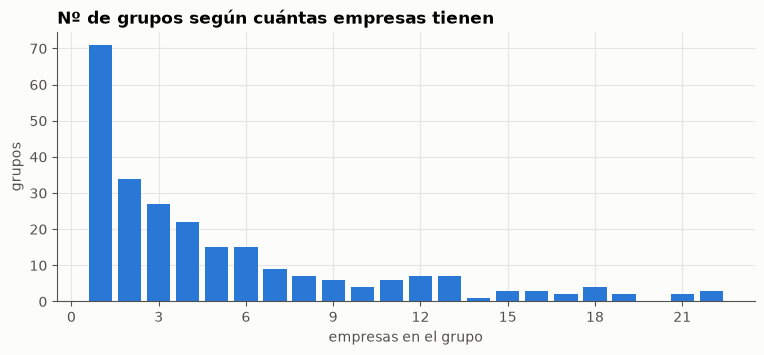

In [4]:
print("Empresas por grupo:", groups.n_companies_in_sample.describe()[["mean", "50%", "max"]].round(1).to_dict())
print("Suma:", groups.n_companies_in_sample.sum(), "empresas | grupos con 1 sola empresa:", (groups.n_companies_in_sample == 1).sum())
print("Grupos sin ERP informado:", pct(groups.erp.isna().mean()))

tam = groups.n_companies_in_sample.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(tam.index, tam.values, color=PAL[0], width=0.8)
ax.set_title("Nº de grupos según cuántas empresas tienen")
ax.set_xlabel("empresas en el grupo"); ax.set_ylabel("grupos")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.show()

**Qué implica:**
- El enunciado habla de "250 empresas", pero hay **250 grupos** con 1.286 sociedades. Lo más probable es que el leaderboard puntúe **por grupo** (60–80 del test oculto sobre 250 son un 25–30%). Hay que confirmarlo con el script de scoring.
- **Validación siempre con split por `group_id`**, porque las filiales de un mismo grupo comparten patrones. Si caen repartidas entre train y test, el modelo hace trampa sin que se note.
- Si la unidad es el grupo, habrá que **agregar las empresas del grupo** (sumar flujos y saldos, y ponderar ratios por tamaño).

## 2 · `companies`

Una fila por empresa: `company_id`, `group_id`, `country`, `currency`, `erp`, `created_at` (alta en la plataforma de Embat).

In [5]:
print(f"companies: {companies.shape[0]:,} filas × {companies.shape[1]} columnas")
companies.head()

companies: 1,286 filas × 6 columnas


,company_id,group_id,country,currency,erp,created_at
0,COMP_0218,GROUP_0113,NaN,EUR,NaN,2025-03-07 12:27:13
1,COMP_0600,GROUP_0113,ES,EUR,NaN,2025-03-07 11:08:05
2,COMP_0721,GROUP_0113,NaN,EUR,NaN,2025-03-07 11:08:29
3,COMP_0995,GROUP_0113,NaN,EUR,NaN,2025-03-07 11:07:23
4,COMP_0148,GROUP_0016,NaN,EUR,NaN,2025-04-21 15:06:56


In [6]:
print("Nulos por columna:"); display(companies.isna().mean().map(pct).to_frame("nulos"))
print("Monedas:", companies.currency.nunique(), "distintas |", "EUR:", pct((companies.currency == "EUR").mean()))
print("País (sucio, mezcla ISO y texto libre):", companies.country.value_counts().head(8).to_dict())

Nulos por columna:


,nulos
company_id,0.0%
group_id,0.0%
country,82.1%
currency,0.0%
erp,42.1%
created_at,0.0%


Monedas: 28 distintas | EUR: 89.3%
País (sucio, mezcla ISO y texto libre): {'ES': 142, 'ESPAÑA': 14, 'NL': 14, 'DE': 11, 'España': 9, 'FR': 6, 'US': 5, 'Portugal': 5}


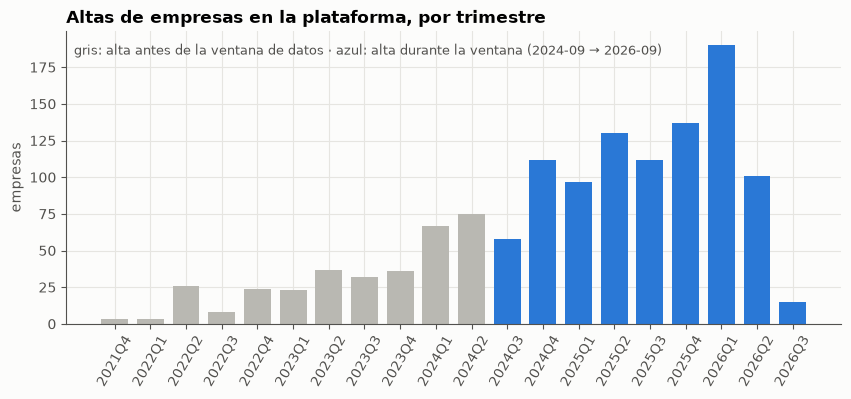

Empresas dadas de alta después de 2024-09-01: 72.2%


In [7]:
q = companies.created_at.dt.to_period("Q").value_counts().sort_index()
en_ventana = q.index.start_time >= "2024-07-01"
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.bar(q.index.astype(str), q.values, color=np.where(en_ventana, PAL[0], MUTED), width=0.75)
ax.set_title("Altas de empresas en la plataforma, por trimestre")
ax.set_ylabel("empresas")
ax.tick_params(axis="x", rotation=60)
ax.text(0.01, 0.92, "gris: alta antes de la ventana de datos · azul: alta durante la ventana (2024-09 → 2026-09)",
        transform=ax.transAxes, color=INK2, fontsize=9)
plt.show()
print("Empresas dadas de alta después de 2024-09-01:", pct((companies.created_at > "2024-09-01").mean()))

In [8]:
# ¿Qué significa que `erp` sea nulo? Cruce con tener facturas (las facturas vienen del ERP conectado)
tiene_facturas = companies.company_id.isin(invoices.company_id)
display(pd.crosstab(companies.erp.notna().map({True: "ERP informado", False: "ERP nulo"}),
                    tiene_facturas.map({True: "con facturas", False: "sin facturas"})))
m = companies.merge(groups[["group_id", "erp"]], on="group_id", suffixes=("", "_grupo")).dropna(subset=["erp", "erp_grupo"])
print("Mismo dato con otra nomenclatura en groups:", m[["erp", "erp_grupo"]].drop_duplicates().head(3).values.tolist())

company_id,con facturas,sin facturas
erp,,
ERP informado,707,38
ERP nulo,78,463


Mismo dato con otra nomenclatura en groups: [['businessOne', 'SAP Business One'], ['sage200', 'Sage 200'], ['dynamicsAx', 'Microsoft Dynamics - AX 2009']]


**Qué implica:**
- **`country` se elimina en la limpieza (regla S01).** Que tenga un 82% de nulos no basta por sí solo: en finanzas, que un dato falte puede ser informativo. Los motivos reales son estos:
  1. *Casi no varía:* de las 230 empresas que lo tienen, ~170 son España escrita de formas distintas (`ES`, `ESPAÑA`, `Espanya`…).
  2. *`currency` ya lleva lo relevante:* las empresas de fuera de la eurozona se distinguen por la moneda, que es lo que afecta a los importes.
  3. *Que falte refleja cómo se hizo el alta, no la salud de la empresa:* las empresas sin país tienen más a menudo el ERP vacío (45% frente a 30%). Usarlo como feature enseñaría al modelo la calidad del onboarding.
  4. *No es coherente dentro del grupo:* 21 de los 62 grupos con país tienen valores distintos entre sus filiales.

  Salvedad: el país sí importa financieramente (plazos legales de pago, régimen concursal, estacionalidad), pero el dataset no permite explotarlo. Detalle en `docs/decisiones.md` (S01).
- **`erp` no es feature, solo contexto de cobertura (decisión D34).** Un `erp` nulo significa casi siempre que no hay ERP conectado: 463 de las 541 empresas sin ERP no tienen facturas, y 707 de las 745 con ERP sí. La falta de facturas es estructural, no "no factura". Sirve para explicar la cobertura en la ficha ("sin ERP conectado: score solo con bancos"). `groups.erp` es el mismo dato con otra nomenclatura (`businessOne` frente a "SAP Business One").
- `currency` sí se usa: hay 28 monedas de empresa (44 contando cuentas y facturas). **Todos los importes se pasan a EUR con un tipo fijo por moneda** (`xray.fx`, decisión D32; ver 7.3).
- **El 72% de las empresas se dio de alta durante la ventana de datos.** Como se ve en la sección 7, sus datos empiezan poco antes del alta, no en 2024-09. Esta es la trampa más importante del dataset.

## 3 · `banking_products`: cuentas bancarias

Una fila por cuenta: `product_id`, `company_id`, `label`, `type`, `bank_name`, `service`, `currency`, `created_at`.

In [9]:
print(f"banking: {banking.shape[0]:,} filas × {banking.shape[1]} columnas")
banking.head()

banking: 5,987 filas × 8 columnas


,product_id,company_id,label,type,bank_name,service,currency,created_at
0,PRODUCT_00001,COMP_1068,CHECKING_01,checking,Banco Sabadell Empresas,sabadell_emp,EUR,2026-02-19 15:46:46
1,PRODUCT_00003,COMP_1198,CHECKING_01,checking,Banco Santander,santander_emp,EUR,2024-02-09 11:17:38
2,PRODUCT_00004,COMP_1191,CHECKING_01,checking,iberCaja,ibercaja,EUR,2025-10-21 11:53:35
3,PRODUCT_00007,COMP_0586,CHECKING_01,checking,Banco Sabadell Empresas,sabadell_emp,EUR,2026-03-03 14:37:27
4,PRODUCT_00008,COMP_0034,CHECKING_01,checking,Bankinter Empresas,bankinter_emp,EUR,2025-05-22 14:56:19


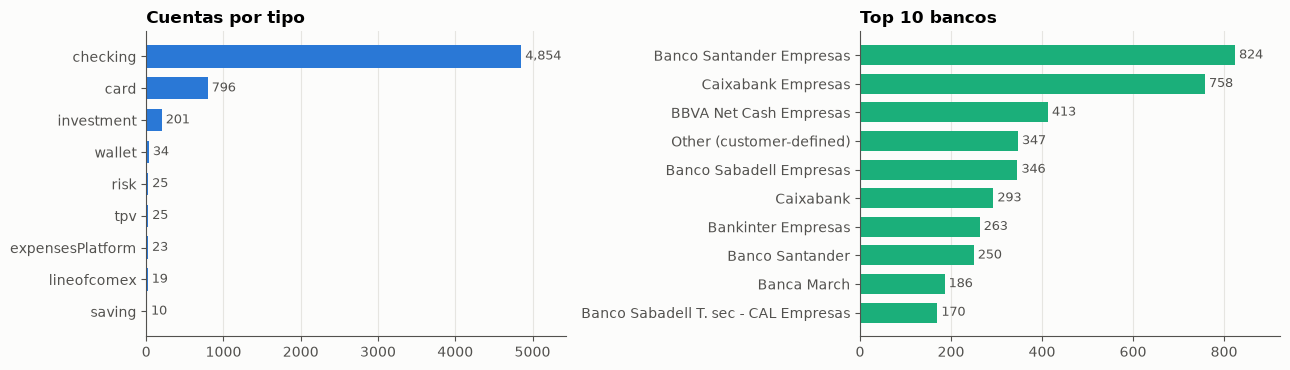

Cuentas por empresa: {'50%': 3.0, 'mean': 4.666406858924396, 'max': 65.0}
Cuentas en moneda distinta de EUR: 17.8%
Empresas sin ninguna cuenta: 3


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
hbar(banking.type.value_counts(), "Cuentas por tipo", ax=axes[0])
hbar(banking.bank_name.value_counts().head(10), "Top 10 bancos", color=PAL[2], ax=axes[1])
plt.tight_layout(); plt.show()

por_emp = banking.groupby("company_id").size()
print("Cuentas por empresa:", por_emp.describe()[["50%", "mean", "max"]].to_dict())
print("Cuentas en moneda distinta de EUR:", pct((banking.currency != "EUR").mean()))
print("Empresas sin ninguna cuenta:", len(set(companies.company_id) - set(banking.company_id)))

**Qué implica:** por sí sola, esta tabla aporta poco al score. Sirve para **clasificar los movimientos y saldos** por tipo de cuenta, con `checking` como la cuenta operativa. Features posibles: nº de bancos (bancarización) y cuentas nuevas conectadas (aunque eso es más onboarding que salud).

## 4 · `debt_products`: financiación

Préstamos, pólizas de crédito (`lineofcredit`), confirming, leasing, avales (`guarantee`), hipotecas, renting y factoring. Tiene las mismas columnas que `banking_products` y además:

| columna | qué es | signo |
|---|---|---|
| `granted` | importe concedido | **negativo** |
| `outstanding` | saldo pendiente (lo que se debe hoy) | **negativo** (o 0) |
| `liquidity` | disponible | positivo |

In [11]:
print(f"debt: {debt.shape[0]:,} filas × {debt.shape[1]} columnas")
debt.head()

debt: 2,239 filas × 11 columnas


,product_id,company_id,label,type,bank_name,service,currency,created_at,granted,outstanding,liquidity
0,PRODUCT_00002,COMP_1008,LOAN_01,loan,Banca March,bancamarch,EUR,2026-01-28 12:50:43,NaN,"-394,699.74",NaN
1,PRODUCT_00005,COMP_0742,LOAN_01,loan,Other (customer-defined),custom,EUR,2026-03-26 10:34:49,"-4,000,000.00","-840,000.00",NaN
2,PRODUCT_00006,COMP_0653,LOAN_01,loan,Other (customer-defined),custom,EUR,2025-08-27 15:31:35,"-350,000.00",0.00,NaN
3,PRODUCT_00023,COMP_0248,LOAN_01,loan,Banco Sabadell T. sec - CAL Empresas,sabadell_emp_sec,EUR,2025-11-13 13:36:02,"-100,000.00","-30,101.12",NaN
4,PRODUCT_00027,COMP_1130,LINEOFCREDIT_01,lineofcredit,Banco Sabadell,sabadell_emp,EUR,2024-05-21 15:04:34,-0.01,0.00,0.01


Empresas con deuda: 378 de 1286 (29.4%) | grupos: 150 de 250

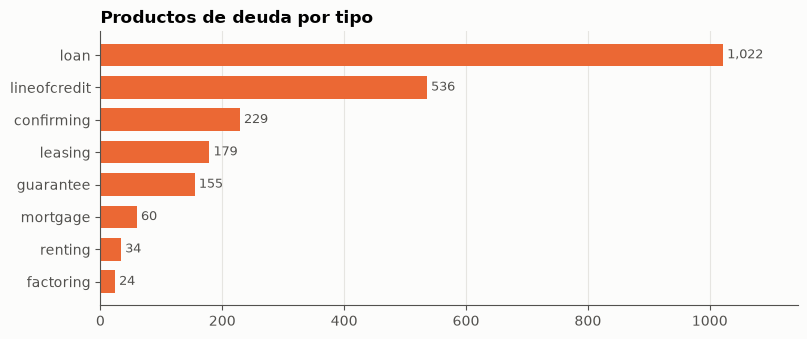

,n,granted_mediano,outstanding_mediano,pct_outstanding_0,pct_con_liquidity
type,,,,,
loan,1022,"-248,204.09","-35,000.00",0.38,0.14
lineofcredit,536,"-250,000.00",-472.55,0.25,0.81
confirming,229,"-900,000.00",0.00,0.64,0.76
leasing,179,"-56,159.71","-30,414.23",0.12,0.06
guarantee,155,"-39,949.58","-39,583.00",0.12,0.14
mortgage,60,"-56,172.49","-49,590.40",0.05,0.00
renting,34,"-12,220.43","-4,057.80",0.41,0.03
factoring,24,"-800,000.00",0.00,0.58,0.88


In [12]:
emp_deuda = debt.company_id.nunique()
print(f"Empresas con deuda: {emp_deuda} de {len(companies)} ({pct(emp_deuda / len(companies))}) | "
      f"grupos: {debt.company_id.map(comp2grp).nunique()} de {len(groups)}")

hbar(debt.type.value_counts(), "Productos de deuda por tipo", color=PAL[1])
plt.show()

por_tipo = debt.groupby("type").agg(
    n=("product_id", "size"),
    granted_mediano=("granted", "median"),
    outstanding_mediano=("outstanding", "median"),
    pct_outstanding_0=("outstanding", lambda s: (s == 0).mean()),
    pct_con_liquidity=("liquidity", lambda s: s.notna().mean()),
).sort_values("n", ascending=False)
por_tipo

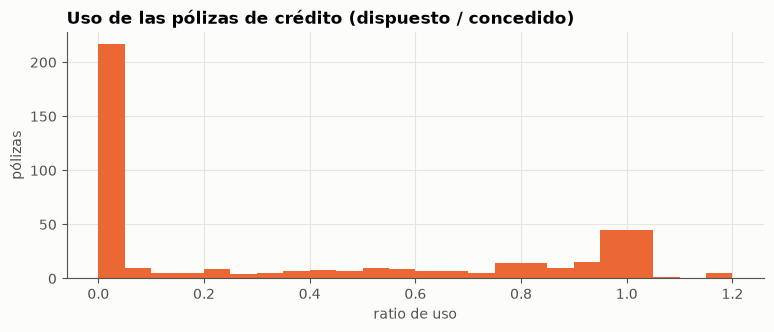

Pólizas usadas por encima del 80%: 28.9%


In [13]:
# Uso de las pólizas de crédito: outstanding / granted (ambos negativos -> ratio positivo)
loc = debt[(debt.type == "lineofcredit") & (debt.granted < 0)]
uso = (loc.outstanding / loc.granted).clip(0, 1.2)
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(uso, bins=24, color=PAL[1])
ax.set_title("Uso de las pólizas de crédito (dispuesto / concedido)")
ax.set_xlabel("ratio de uso"); ax.set_ylabel("pólizas")
plt.show()
print("Pólizas usadas por encima del 80%:", pct((uso > 0.8).mean()))

**Qué implica:**
- Solo el **29% de las empresas** tiene deuda registrada, así que las features de deuda tienen que ser **opcionales** y aceptar nulos. No tener deuda registrada no equivale a no tener deuda.
- `outstanding` es una **foto final**, no una serie. La dinámica de la deuda hay que sacarla de las transacciones (`debt_repayment`, `interest_charge` y los movimientos en cuentas `lineofcredit`).
- Señales de tensión clásicas: **póliza al límite**, uso de **factoring o confirming** (necesidad de circulante) y avales.

## 5 · `debt_schedule_config`: cuadros de amortización

Una fila por préstamo con cuadro formal: tipo de cuota, frecuencia, nº de plazos, tipo de interés y fechas de pago.

In [14]:
print(f"schedule: {schedule.shape[0]:,} filas × {schedule.shape[1]} columnas")
schedule.head()

schedule: 87 filas × 14 columnas


,product_id,company_id,settlement_product_id,currency,amortization_type,interest_calc_method,amortising_frequency,granted_balance,outstanding_balance,total_periods,next_payment_date,last_payment_date,annual_interest_rate_or_spread,interest_type
0,PRODUCT_06719,COMP_0047,PRODUCT_04535,EUR,constant quote,30/360,monthly,"270,000.00","154,978.58",33,2025-09-30,2025-09-16 12:31:20,0.04,fixed
1,PRODUCT_04223,COMP_0203,PRODUCT_00862,EUR,constant quote,30/360,monthly,"1,000,000.00","1,000,000.00",84,2026-09-01,2026-08-06 14:14:16,0.03,fixed
2,PRODUCT_04218,COMP_0058,PRODUCT_03752,EUR,constant quote,30/360,monthly,"1,235,500.00","1,235,500.00",67,2026-07-09,2026-06-09 11:49:36,0.03,fixed
3,PRODUCT_03014,COMP_0906,PRODUCT_06629,EUR,constant quote,30/360,monthly,"300,000.00","201,324.47",39,2026-03-30,2026-03-10 17:05:19,0.04,fixed
4,PRODUCT_03158,COMP_0721,PRODUCT_03880,EUR,constant quote,30/360,monthly,"1,000,000.00","464,024.64",26,2026-03-11,2026-02-17 17:44:05,0.04,fixed


In [15]:
print("Filas:", len(schedule), "| empresas:", schedule.company_id.nunique())
for col in ["amortization_type", "amortising_frequency", "interest_type"]:
    print(f"{col:22s}", schedule[col].value_counts().to_dict())
print("Tipo producto:", debt.set_index("product_id").type.reindex(schedule.product_id).value_counts().to_dict())
schedule[["granted_balance", "outstanding_balance", "total_periods", "annual_interest_rate_or_spread"]].describe().T[["50%", "mean", "min", "max"]]

Filas: 87 | empresas: 40
amortization_type      {'constant quote': 87}
amortising_frequency   {'monthly': 79, 'quarterly': 5, 'semiannually': 3}
interest_type          {'fixed': 58, 'variable': 29}
Tipo producto: {'loan': 75, 'leasing': 7, 'guarantee': 2, 'renting': 2, 'mortgage': 1}


,50%,mean,min,max
granted_balance,"750,000.00","4,884,639.05",0.00,"300,000,000.00"
outstanding_balance,"314,442.60","4,865,371.43",2.43,"300,000,000.00"
total_periods,43.00,49.46,1.00,180.00
annual_interest_rate_or_spread,0.03,0.03,0.00,0.11


**Qué implica:** cubre solo a **40 empresas**, así que no da para una feature general del score. Sirve para el **producto** (por ejemplo, "te vienen estas cuotas", simulaciones de refinanciación) o como contexto en la ficha de empresa. El coste de la deuda (`annual_interest_rate_or_spread`, mediana del 3%) es interesante, pero está muy poco poblado.

## 6 · `balances`: una sola foto

Saldo de cada producto (cuenta o deuda) **a 2026-09-01**. No es una serie temporal.

In [16]:
print(f"balances: {balances.shape[0]:,} filas × {balances.shape[1]} columnas")
balances.head()

balances: 7,996 filas × 8 columnas


,product_id,company_id,date,balance,available,granted,liquidity,countable
0,PRODUCT_03496,COMP_0001,2026-09-01,"31,795.29",NaN,NaN,NaN,NaN
1,PRODUCT_04955,COMP_0001,2026-09-01,681.97,NaN,NaN,NaN,NaN
2,PRODUCT_02455,COMP_0002,2026-09-01,"926,103.68",NaN,NaN,"926,103.68","926,103.68"
3,PRODUCT_03252,COMP_0002,2026-09-01,"135,177.36",NaN,NaN,"135,177.36","135,177.36"
4,PRODUCT_03244,COMP_0003,2026-09-01,"1,052.77",NaN,NaN,NaN,NaN


In [17]:
print("Fechas:", balances.date.value_counts().head(4).to_dict())
print("Nulos:", balances.isna().mean().map(pct).to_dict())
tipos = pd.concat([banking[["product_id", "type"]], debt[["product_id", "type"]]])
b = balances.merge(tipos, on="product_id", how="left")
print("Productos sin tipo conocido:", b.type.isna().sum())
b.groupby("type").agg(n=("balance", "size"), saldo_mediano=("balance", "median"),
                      pct_negativo=("balance", lambda s: (s < 0).mean()),
                      pct_cero=("balance", lambda s: (s == 0).mean())).sort_values("n", ascending=False)

Fechas: {Timestamp('2026-09-01 00:00:00'): 7980, Timestamp('2026-08-28 00:00:00'): 8, Timestamp('2026-08-27 00:00:00'): 5, Timestamp('2026-08-25 00:00:00'): 2}
Nulos: {'product_id': '0.0%', 'company_id': '0.0%', 'date': '0.0%', 'balance': '0.0%', 'available': '100.0%', 'granted': '66.9%', 'liquidity': '76.3%', 'countable': '91.7%'}
Productos sin tipo conocido: 29


,n,saldo_mediano,pct_negativo,pct_cero
type,,,,
checking,4647,"6,781.88",0.02,0.20
loan,1006,"-36,844.13",0.60,0.38
card,794,0.00,0.34,0.58
lineofcredit,532,-123.75,0.53,0.23
confirming,227,0.00,0.32,0.64
investment,185,"61,779.19",0.01,0.19
leasing,176,"-33,616.75",0.90,0.10
guarantee,149,"-39,583.00",0.89,0.11
mortgage,60,"-49,882.47",0.95,0.05


**Qué implica:**
- Las cuentas de pasivo (loan, leasing, mortgage…) salen en negativo y las de activo (checking, investment) en positivo, con la misma convención que `debt_products`.
- Con una sola foto no hay trayectoria. **El truco (sección 9.3):** combinando el saldo final con las transacciones se reconstruye el **saldo histórico** de cada cuenta hacia atrás.

## 7 · `transactions`: el corazón del dataset

2,56 M movimientos bancarios de 2024-09-01 a 2026-09-01.

| columna | qué es |
|---|---|
| `date` / `value_date` | fecha contable / fecha valor (`value_date` tiene basura, p. ej. 2099-12-31: usad `date`) |
| `amount` | **positivo = entra, negativo = sale**, en la moneda de la cuenta |
| `status` | `booked` / `pending` |
| `accounting_status` | estado de conciliación con el ERP (62% nulo) |
| `category` | categoría automática (`collection`, `payment`, `salary`, `tax`…) |
| `description` | concepto del banco, anonimizado con placeholders (`[COMPANY]`, `[NUM]`, `COUNTERPARTY_x`…) |
| `counterparty_id` | contraparte resuelta (90% nulo) |

In [18]:
print(f"tx: {tx.shape[0]:,} filas × {tx.shape[1]} columnas")
tx.head()

tx: 2,556,437 filas × 12 columnas


,transaction_id,company_id,product_id,date,value_date,amount,exchange_rate,status,accounting_status,category,description,counterparty_id
0,031b6af5e65957a71747a25f819ee269,COMP_0194,PRODUCT_00121,2025-02-15 00:00:00,2025-02-15 00:00:00,-12.00,1.00,booked,RECONCILIATION_COMPLETED,interest_charge,LIQUIDACION DE INTERESES-COMISIONES-GASTOS,NaN
1,03a15fa458d766b1352ca54a9578cdcc,COMP_1062,PRODUCT_02914,2026-08-01 00:00:00,2026-07-27 00:00:00,371.00,1.00,booked,RECONCILIATION_COMPLETED,payment_refund,PAGO DEVOLUCION,COUNTERPARTY_00001
2,2487f735eaf4598a19c1b79f5e35ae1f,COMP_1149,PRODUCT_00693,2026-01-15 00:00:00,2026-01-15 00:00:00,73.60,1.00,booked,NaN,payment_refund,DEVOLUCION COMPRA COUNTERPARTY_18137 COUNTERPA...,NaN
3,2969ff9d3806cc44558657852b7429ae,COMP_0870,PRODUCT_06316,2025-09-05 00:00:00,2025-09-05 00:00:00,-994.89,1.00,booked,PENDING,pos_withdrawal,Tarjeta credito [NAME]- DocNum:[NUM],NaN
4,33H325402M648612Y,COMP_1086,PRODUCT_04834,2026-04-16 16:39:16,2026-04-16 16:39:16,-194.69,1.00,booked,NaN,collection_refund,"[REF] [PERSON] [ES] Reembolso de pago, iniciad...",NaN


In [19]:
print("Rango date:", tx.date.min(), "→", tx.date.max(), "| value_date máx:", tx.value_date.max())
print("Nulos:"); display(tx.isna().mean().map(pct).to_frame("nulos").T)
print("status:", tx.status.value_counts(dropna=False).to_dict())
print("Movimientos que son entradas:", pct((tx.amount > 0).mean()), "| exchange_rate != 1:", pct((tx.exchange_rate != 1).mean()))

Rango date: 2024-09-01 00:00:00 → 2026-09-01 23:37:04 | value_date máx: 2099-12-31 01:00:00
Nulos:


,transaction_id,company_id,product_id,date,value_date,amount,exchange_rate,status,accounting_status,category,description,counterparty_id
nulos,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,0.0%,1.2%,61.6%,0.0%,0.0%,90.2%


status: {'booked': 2520019, nan: 29839, 'pending': 6579}
Movimientos que son entradas: 41.1% | exchange_rate != 1: 4.0%


### 7.1 · Categorías

La categoría dice **qué tipo de flujo** es cada movimiento, y es la base de casi todas las features de caja.

,n,pct_entradas,importe_mediano,empresas
category,,,,
-,635530,0.35,-26.98,1213
collection,567417,1.00,859.54,1259
payment,362276,0.00,-857.53,1205
utility,259430,0.00,-147.91,1123
fee,179500,0.00,-5.40,1049
transfer,152102,0.60,162.76,925
bulk_collection,65492,1.00,682.65,263
tax,55904,0.02,-392.69,1155
cash_settlement,48280,1.00,"1,351.25",631


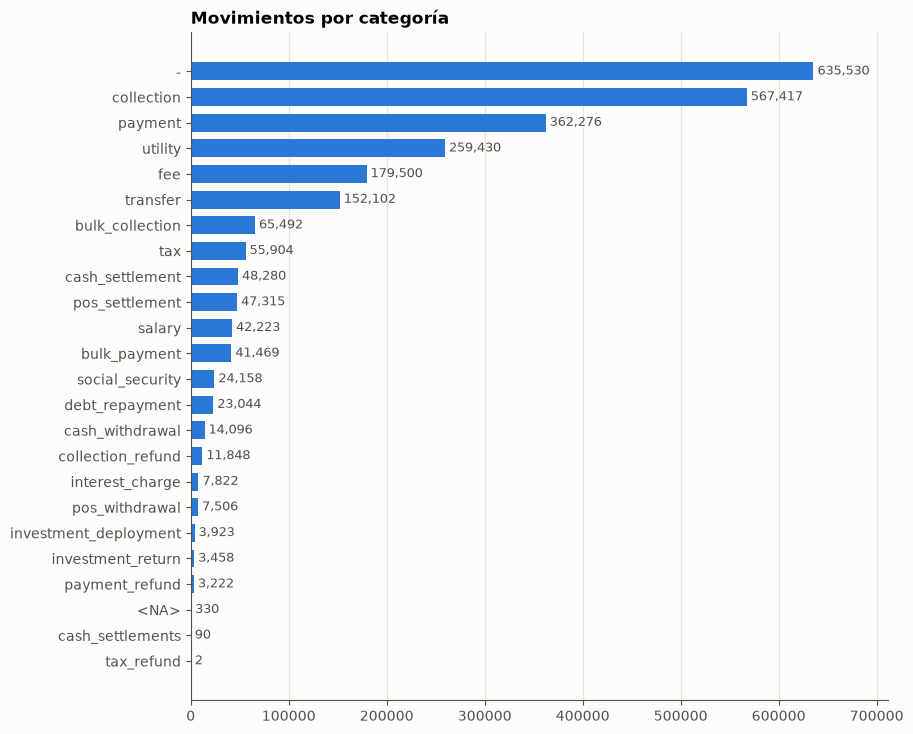

In [20]:
cat = (tx.assign(category=tx.category.fillna("<NA>"))
         .groupby("category")
         .agg(n=("amount", "size"),
              pct_entradas=("amount", lambda s: (s > 0).mean()),
              importe_mediano=("amount", "median"),
              empresas=("company_id", "nunique"))
         .sort_values("n", ascending=False))
display(cat)
hbar(cat.n, "Movimientos por categoría")
plt.show()

- **`-` = sin categorizar: 25% de los movimientos.** Mezcla entradas y salidas. Se puede ignorar (perdiendo señal) o recategorizar con reglas sobre `description`.
- Las categorías tienen un signo casi puro (`collection` siempre entra, `payment` siempre sale), así que se agrupan bien:
  - **Entradas operativas:** `collection`, `bulk_collection`, `pos_settlement`, `cash_settlement`
  - **Salidas operativas:** `payment`, `bulk_payment`, `utility`
  - **Gastos fijos estructurales:** `salary`, `social_security`, `tax`
  - **Coste de la deuda:** `debt_repayment`, `interest_charge`, `fee`
  - **Movimientos que no son negocio:** `transfer` (traspasos entre cuentas propias), `investment_*`

### 7.2 · El efecto onboarding (la trampa principal)

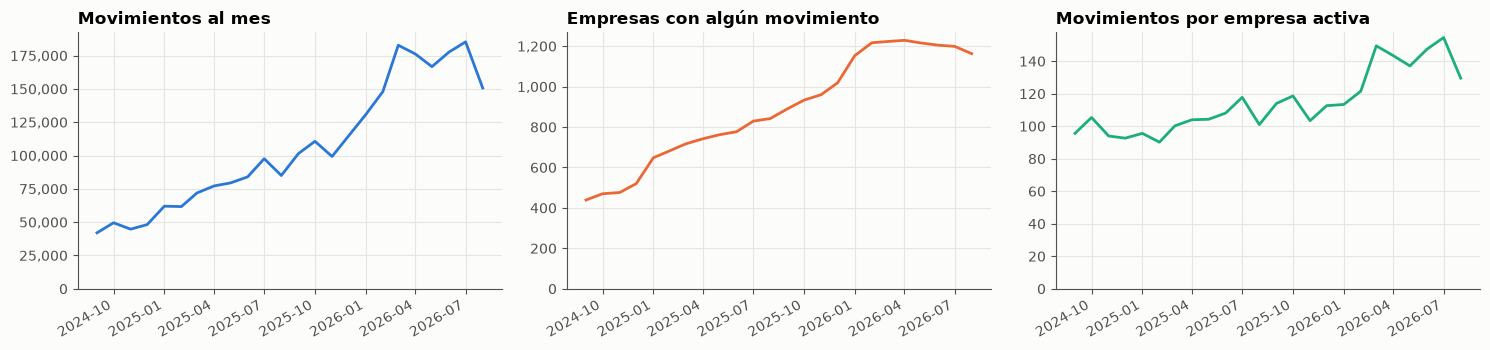

In [21]:
tx["mes"] = tx.date.dt.to_period("M")
txm = tx[tx.date < "2026-09-01"]                  # 2026-09 solo tiene 1 día
por_mes = txm.groupby("mes").agg(movimientos=("amount", "size"), empresas_activas=("company_id", "nunique"))
por_mes["movs_por_empresa"] = por_mes.movimientos / por_mes.empresas_activas
x = por_mes.index.to_timestamp()

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
for ax, col, titulo, c in zip(axes, por_mes.columns,
                              ["Movimientos al mes", "Empresas con algún movimiento", "Movimientos por empresa activa"], PAL):
    ax.plot(x, por_mes[col], color=c)
    ax.set_title(titulo); ax.set_ylim(0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

El volumen total **se multiplica por 4**, pero los movimientos por empresa activa se mantienen bastante planos. **No es crecimiento del negocio: son empresas que se van incorporando.** Cada una trae unos dos meses de histórico al conectar su banco (la primera transacción cae de mediana unos 40 días antes de `created_at`).

Meses con datos por empresa: {'min': 1.0, '25%': 10.0, '50%': 18.0, '75%': 24.0}
Grupos con los 24 meses completos: 86 de 250
Días entre la 1ª transacción y el alta (created_at), mediana: -40.0


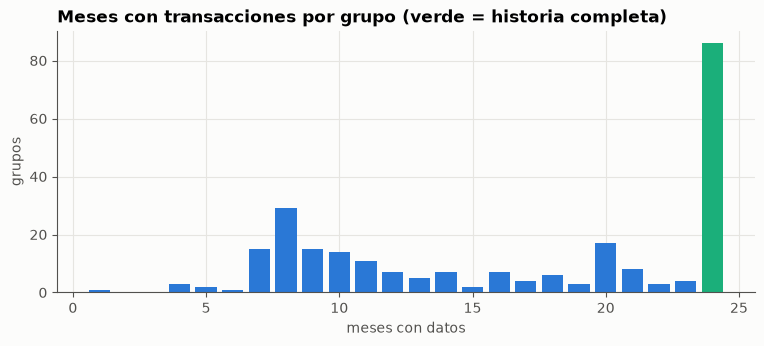

In [22]:
cov_emp = txm.groupby("company_id").mes.nunique()
cov_grp = txm.assign(g=txm.company_id.map(comp2grp)).groupby("g").mes.nunique()
primera = txm.groupby("company_id").date.min()
lag = (primera - companies.set_index("company_id").created_at).dt.days

print("Meses con datos por empresa:", cov_emp.describe()[["min", "25%", "50%", "75%"]].to_dict())
print("Grupos con los 24 meses completos:", (cov_grp >= 24).sum(), "de", len(cov_grp))
print("Días entre la 1ª transacción y el alta (created_at), mediana:", lag.median())

v = cov_grp.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(v.index, v.values, color=np.where(v.index >= 24, PAL[2], PAL[0]), width=0.8)
ax.set_title("Meses con transacciones por grupo (verde = historia completa)")
ax.set_xlabel("meses con datos"); ax.set_ylabel("grupos")
plt.show()

In [23]:
# ¿El primer mes con datos está completo? Cobros por mes contado desde el primer movimiento
entradas_op = ["collection", "bulk_collection", "pos_settlement", "cash_settlement"]
primero = txm.groupby("company_id").date.min()
tardias = primero[primero >= "2024-09-05"].index                 # entran a mitad de ventana, no en su inicio
c = txm[txm.company_id.isin(tardias) & txm.category.isin(entradas_op)]
mes_n = c.date.dt.year * 12 + c.date.dt.month
k = mes_n - c.company_id.map(primero.dt.year * 12 + primero.dt.month)
rel = c.assign(k=k)[k.between(0, 5)].groupby(["company_id", "k"]).size().unstack()
print("Día del mes del primer movimiento (mediana):", primero[tardias].dt.day.median())
print("Actividad del mes 0 frente al mes 2 (mediana):", pct((rel[0] / rel[2]).median()),
      "| mes 1 frente al mes 2:", pct((rel[1] / rel[2]).median()))
print("Empresas cuyo primer mes es 2024-09 (inicio de la extracción), día del 1er movimiento:",
      primero[primero < "2024-09-05"].dt.day.value_counts().head(3).to_dict())
display(rel.median().rename("cobros (mediana)").to_frame().T)

Día del mes del primer movimiento (mediana): 14.0
Actividad del mes 0 frente al mes 2 (mediana): 60.3% | mes 1 frente al mes 2: 100.0%
Empresas cuyo primer mes es 2024-09 (inicio de la extracción), día del 1er movimiento: {2: 185, 1: 124, 3: 35}


k,0,1,2,3,4,5
cobros (mediana),4.00,7.00,9.00,8.00,9.00,8.00


**Qué implica:**
- **Solo 86 de 250 grupos tienen los 24 meses** (sin contar el día suelto de 2026-09). El resto empieza a mitad de ventana.
- Un mes anterior a la primera transacción **no es actividad cero, es ausencia de dato**. Hay que enmascararlo como NaN.
- Nunca hay que usar tendencias de volumen absoluto sin corregir la cobertura, porque el modelo aprendería "cuándo se dio de alta" en lugar de "cómo está".
- Las features de dinámica (pendiente a 3/6 meses) necesitan un **mínimo de historia**, y el score debe saber funcionar con poca historia (el test oculto también tendrá grupos cortos).
- **El primer mes de quien entra a mitad de ventana está incompleto (decisión D33).** El primer movimiento cae de mediana a mitad de mes y ese mes tiene ~60% de la actividad normal; el siguiente ya es normal. Si entra en las ventanas, al mes siguiente aparece un crecimiento falso de ~+60%. Se marca con `is_partial_first_month` y sus importes no cuentan (se conservan los conteos). No aplica al primer mes de la extracción (2024-09): esas empresas ya existían y sus datos empiezan el día 1–3, así que el mes está completo.
- `created_at` no marca el inicio de la historia: el primer movimiento cae de mediana ~54 días antes del alta. La historia empieza en el primer movimiento.

### 7.3 · Importes grandes, monedas y contrapartes

In [24]:
# Moneda de cada movimiento = moneda de su cuenta/producto; importe convertido a EUR con tipo fijo
prod_ccy = pd.concat([banking[["product_id", "currency"]], debt[["product_id", "currency"]]]).drop_duplicates("product_id")
tx["product_currency"] = tx.product_id.map(prod_ccy.set_index("product_id").currency)
tx["amount_eur"] = to_eur(tx.amount, tx.product_currency)
print(f"Tipos fijos a fecha {FX_ASOF} | movimientos sin moneda conocida (producto desconocido): {tx.amount_eur.isna().sum():,}")

big_local = tx.amount.abs() > 1e8
big_eur = tx.amount_eur.abs() > 1e8
print(f"|amount| > 100M en moneda local: {big_local.sum()} filas en {tx.company_id[big_local].nunique()} empresas")
print(f"|amount| > 100M€ tras convertir:  {big_eur.sum()} filas en {tx.company_id[big_eur].nunique()} empresas")
display(tx[big_local].groupby("product_currency")
          .agg(filas=("amount", "size"), empresas=("company_id", "nunique"),
               mediana_local=("amount", lambda s: s.abs().median()),
               mediana_eur=("amount_eur", lambda s: s.abs().median()))
          .sort_values("filas", ascending=False))
display(tx[big_eur][["company_id", "date", "amount", "product_currency", "amount_eur", "category", "description"]])

tiene_token = tx.description.str.contains("COUNTERPARTY_", regex=False, na=False)
print("counterparty_id informado:", pct(tx.counterparty_id.notna().mean()),
      "| con token COUNTERPARTY_ en la descripción:", pct(tiene_token.mean()))

Tipos fijos a fecha 2026-09-18 | movimientos sin moneda conocida (producto desconocido): 1,314
|amount| > 100M en moneda local: 491 filas en 22 empresas
|amount| > 100M€ tras convertir:  13 filas en 7 empresas


,filas,empresas,mediana_local,mediana_eur
product_currency,,,,
COP,262,6,"238,798,784.97","66,422.55"
AOA,135,2,"300,000,000.00","273,163.58"
VND,39,1,"300,249,672.00","10,050.37"
CLP,28,4,"143,598,634.50","130,350.27"
EUR,11,6,"300,000,000.00","300,000,000.00"
XOF,10,1,"200,000,000.00","304,898.03"
ARS,4,1,"201,149,959.61","115,868.74"
USD,2,1,"168,456,593.12","146,995,281.95"


,company_id,date,amount,product_currency,amount_eur,category,description
524611,COMP_0604,2024-12-31,"999,999,999.00",EUR,"999,999,999.00",-,R. VILLAS MANUAL QUITAR RETENCION
1220566,COMP_0538,2025-01-01,"999,999,999.00",EUR,"999,999,999.00",-,AJUSTE RETENCION CC ESPECIAL
1340772,COMP_0080,2025-07-18,"-157,500,030.00",EUR,"-157,500,030.00",payment,TRANSFERENCIA A FAVOR DE [COMPANY] [X] COUNTER...
1452844,COMP_0604,2024-12-31,"999,999,999.00",EUR,"999,999,999.00",-,VALLEY 5 Y 6 MANUAL QUITAR RETENCION
1454445,COMP_0262,2025-07-28,"-155,766,118.26",USD,"-135,921,569.16",-,REC [X]=[NUM];[X]=[X] [X] 07.28.2025 CREDIT RE...
1661667,COMP_0604,2024-12-31,"999,999,999.00",EUR,"999,999,999.00",-,R. [X] MANUAL QUITAR RETENCION
1674527,COMP_0415,2026-04-29,"300,000,000.00",EUR,"300,000,000.00",-,[NUM]-DISPOSICION TERM LOAN CREDITOS - [COMPANY]
1721420,COMP_0080,2025-07-18,"157,500,000.00",EUR,"157,500,000.00",collection,"TRANSFERENCIA DE [COMPANY]., CONCEPTO REPARTO ..."
1749268,COMP_0994,2025-07-03,"105,000,000.00",EUR,"105,000,000.00",collection,"OP [X], OSN [NUM] COUNTERPARTY_24419 A"
1875070,COMP_0262,2025-07-28,"181,147,067.97",USD,"158,068,994.74",-,B/O BANK=ABA/[NUM] [X] NATIONAL ASSOCIATION 49...


counterparty_id informado: 9.8% | con token COUNTERPARTY_ en la descripción: 25.3%


**Qué implica:**
- Un umbral en moneda local no tiene sentido: 100M COP son unas decenas de miles de euros. Casi todos los movimientos de más de 100M son **flujos normales de empresas en COP, AOA, VND o CLP**. En euros de verdad solo quedan una docena de movimientos muy grandes.
- **Decisión D32: no se elimina ningún movimiento por su importe.** Si existe, se conserva. Los importes se comparan y se agregan en EUR, convertidos con **un tipo fijo por moneda** (`src/xray/fx.py`): BCE a 2026-09-18 y, para las monedas que el BCE no publica, open.er-api.com o la paridad oficial (BAM, XOF).
- Es una aproximación: con un tipo fijo se pierde la variación del cambio en 24 meses (en ARS es grande). **Mejora futura:** tipos diarios por moneda aplicados en la fecha de cada movimiento. `exchange_rate` de la tabla no se usa: en algunas monedas parece ir contra USD (HKD 7,83) y no cubre todas.
- La contraparte solo está resuelta en ~10% de los movimientos.

### 7.4 · Señales de estrés en el texto del banco

La descripción anonimizada conserva palabras clave. Algunas son en la vida real **señales muy fuertes de problemas**.

In [25]:
desc = tx.description.fillna("").str.upper()
claves = {
    "EMBARGO": "EMBARGO", "IMPAGADO": "IMPAGAD", "DEVOLUCIÓN / DEVUELTO": "DEVOLUCI|DEVUELT",
    "APLAZAMIENTO (Hacienda/SS)": "APLAZAM", "DESCUBIERTO / EXCEDIDO": "DESCUBIERT|EXCEDID",
    "INTERESES DE DEMORA": "DEMORA", "RECARGO": "RECARGO", "FACTORING": "FACTORING", "ANTICIPO": "ANTICIPO",
}
filas = []
for nombre, patron in claves.items():
    m = desc.str.contains(patron, regex=True)
    filas.append({"señal": nombre, "movimientos": int(m.sum()), "empresas": tx.company_id[m].nunique(),
                  "grupos": tx.company_id[m].map(comp2grp).nunique(),
                  "categoría principal": tx.category[m].value_counts().index[0]})
estres = pd.DataFrame(filas).set_index("señal").sort_values("empresas")
estres

,movimientos,empresas,grupos,categoría principal
señal,,,,
INTERESES DE DEMORA,111,31,24,-
RECARGO,95,37,29,utility
APLAZAMIENTO (Hacienda/SS),801,62,30,payment
DESCUBIERTO / EXCEDIDO,283,95,62,utility
IMPAGADO,8253,157,78,collection_refund
EMBARGO,646,159,92,tax
FACTORING,3711,165,93,collection
ANTICIPO,5707,289,131,payment
DEVOLUCIÓN / DEVUELTO,18539,779,192,collection_refund


**Qué implica:** `EMBARGO`, `IMPAGADO`, `APLAZAMIENTO` y `DESCUBIERTO` son **eventos raros y muy claros**, que afectan a entre 30 y 160 empresas. Tienen dos usos:
1. **Construir el target** (si el leaderboard no lo da): "¿tendrá un embargo/impago/aplazamiento en los próximos 3–6 meses?"
2. **La regla independiente** para medir la anticipación (ver "Enfoque acordado" en `CLAUDE.md`): el momento en que el deterioro ya es evidente.

Ojo: si se usan como target, **no pueden ser a la vez features del mismo horizonte** (sería fuga).

### 7.5 · Estacionalidad

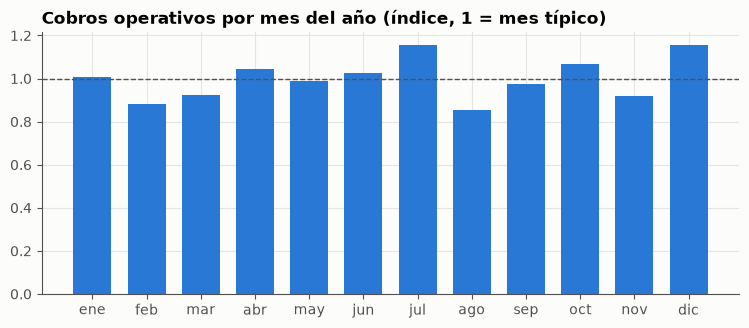

In [26]:
entradas_op = ["collection", "bulk_collection", "pos_settlement", "cash_settlement"]
ent = (txm[txm.category.isin(entradas_op) & (txm.amount.abs() < 1e8)]
       .groupby(["company_id", "mes"]).amount.sum().reset_index())
ent = ent[ent.groupby("company_id").mes.transform("size") >= 12]            # empresas con >= 12 meses
ent["indice"] = ent.amount / ent.groupby("company_id").amount.transform("mean")
estac = ent.groupby(ent.mes.dt.month).indice.median()
estac = estac / estac.mean()                                                # 1 = mes típico

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(estac.index, estac.values, color=PAL[0], width=0.7)
ax.axhline(1, color=INK2, lw=1, ls="--")
ax.set_xticks(range(1, 13), ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"])
ax.set_title("Cobros operativos por mes del año (índice, 1 = mes típico)")
plt.show()

Los cobros caen en **agosto y febrero** y suben en **julio y diciembre**. Un mes malo puede ser solo agosto. Para distinguir **bache de caída** (una de las seis preguntas del enunciado) hay que **comparar contra el mismo mes del año anterior o desestacionalizar**. Además, las tendencias deben medirse sobre ventanas de 3–6 meses, no mes a mes.

## 8 · `invoices`: facturas del ERP

~900 K facturas emitidas y recibidas, sincronizadas desde el ERP de cada empresa.

| columna | qué es |
|---|---|
| `document_type` | `invoice`, `note`, `paymentDocument`, `deposit`, `refund`… |
| `issuance_date` / `due_date` / `payment_date` | emisión / vencimiento / pago |
| `amount` | **positivo = emitida (a cobrar, AR)**, **negativo = recibida (a pagar, AP)** |
| `pending_amount` | lo que queda por cobrar o pagar (0 si está saldada) |
| `status` | `paid`, `overdue`, `pending`, `cancel`… |
| `counterparty_id` | cliente o proveedor (1% nulo; mucho mejor que en transacciones) |

In [27]:
print(f"invoices: {invoices.shape[0]:,} filas × {invoices.shape[1]} columnas")
invoices.head()

invoices: 897,894 filas × 14 columnas


,operation_id,company_id,document_type,issuance_date,due_date,payment_date,amount,pending_amount,currency,accounting_currency,exchange_rate,status,concept,counterparty_id
0,00229f2507386496cf94639ebac785f3,COMP_0556,invoice,2025-11-29,2025-12-29,2025-12-29,-720.00,0.00,SEK,DKK,1.47,paid,Cph tem event,COUNTERPARTY_47797
1,002966c44ccf446693aaa3ddb659586d,COMP_0915,invoiceGroup,2025-11-07,2025-12-10,2025-12-10,-600.00,0.00,EUR,EUR,1.00,paid,PAGO-[X][NUM],COUNTERPARTY_26837
2,003a4a819fda8de719e8088de420e683,COMP_0023,invoice,2026-07-13,2026-08-12,2026-08-12,-584.20,0.00,EUR,EUR,1.00,paid,Resto Tech summit,COUNTERPARTY_29249
3,00b6925d868b2a127140d7542b90ccf6,COMP_0416,invoice,2026-07-31,2026-07-31,2026-07-31,"-1,815.00",0.00,EUR,EUR,1.00,paid,S/Fra. 24032 - REMESA 10996,COUNTERPARTY_43339
4,00f2f025a0eab5f1987af8d1b3babdad,COMP_0094,invoice,2026-08-01,2026-08-10,2026-08-10,-84.12,0.00,EUR,EUR,1.00,paid,FC [NUM] (31/07/26) 18447 F26 515,COUNTERPARTY_12080


In [28]:
inv = invoices[invoices.amount != 0].copy()
inv["dir"] = np.where(inv.amount > 0, "AR (a cobrar)", "AP (a pagar)")
print("Empresas con facturas:", inv.company_id.nunique(), "de", len(companies),
      "| grupos:", inv.company_id.map(comp2grp).nunique(), "de", len(groups))
print("Reparto:", inv.dir.value_counts(normalize=True).map(pct).to_dict())
display(pd.crosstab(inv.status, inv.dir, margins=True))
display(pd.crosstab(inv.document_type, inv.dir))

Empresas con facturas: 785 de 1286 | grupos: 167 de 250
Reparto: {'AP (a pagar)': '59.1%', 'AR (a cobrar)': '40.9%'}


dir,AP (a pagar),AR (a cobrar),All
status,,,
cancel,9286,4297,13583
overdue,92077,100473,192550
paid,410232,249019,659251
paymentOrder,243,163,406
payment_in_progress,1206,10,1216
pending,17001,12703,29704
shipped,0,1,1
All,530045,366666,896711


dir,AP (a pagar),AR (a cobrar)
document_type,,
cheque,0,12
deliveryNote,2116,4209
deposit,9557,11833
invoice,449558,309849
invoiceGroup,9223,4551
note,20232,17857
other,370,369
paymentDocument,36774,16987
purchaseOrder,1136,71


### 8.1 · La trampa de `status` y `payment_date`

`status` es la **foto a fecha de extracción** (septiembre de 2026), no el estado de cada mes. Además, `payment_date` **nunca es nulo**, ni siquiera en facturas impagadas.

In [29]:
inv["pago_igual_venc"] = inv.payment_date == inv.due_date
inv["pendiente_total"] = (inv.pending_amount.abs() >= inv.amount.abs() * 0.999)
(inv.groupby("status")
    .agg(n=("amount", "size"),
         payment_date_nulo=("payment_date", lambda s: s.isna().mean()),
         payment_date_igual_a_due=("pago_igual_venc", "mean"),
         pendiente_todo_el_importe=("pendiente_total", "mean"))
    .sort_values("n", ascending=False))

,n,payment_date_nulo,payment_date_igual_a_due,pendiente_todo_el_importe
status,,,,
paid,659251,0.00,0.52,0.00
overdue,192550,0.00,0.96,0.97
pending,29704,0.00,0.98,0.99
cancel,13583,0.00,0.81,0.08
payment_in_progress,1216,0.00,0.99,0.98
paymentOrder,406,0.00,1.00,0.01
shipped,1,0.00,1.00,1.00


En las facturas `overdue` y `pending`, **`payment_date` es un relleno igual a `due_date`** en el 96–98% de los casos y el importe sigue entero pendiente. **La fecha de pago real solo es fiable si `status == "paid"`.**

Para tener features **sin fuga temporal** hay que reconstruir, para cada mes *t*, qué facturas estaban abiertas en ese momento:

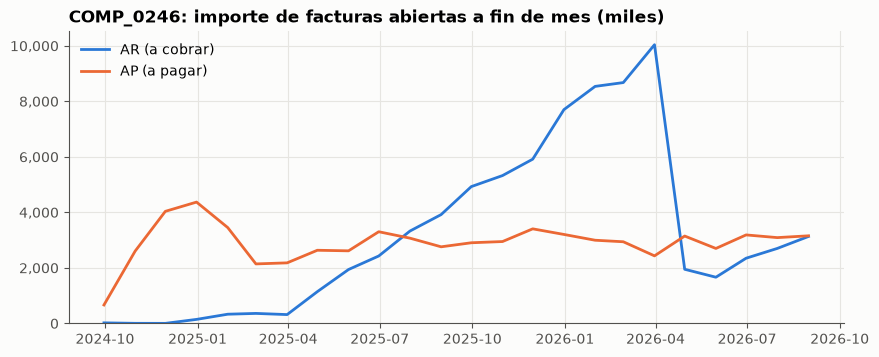

In [30]:
def facturas_abiertas(inv, fecha):
    """Facturas emitidas antes de `fecha` que todavía no se habían pagado/cancelado en `fecha`."""
    fecha = pd.Timestamp(fecha)
    emitida = inv.issuance_date <= fecha
    cerrada = inv.status.isin(["paid", "cancel"]) & (inv.payment_date <= fecha)
    return inv[emitida & ~cerrada]

# Ejemplo: la empresa con más facturas, importe abierto a fin de cada mes
emp = inv.company_id.value_counts().index[0]
d = inv[inv.company_id == emp]
fechas = pd.date_range("2024-09-30", "2026-08-31", freq="ME")
abiertas = pd.DataFrame({f: facturas_abiertas(d, f).groupby("dir").amount.sum().abs() for f in fechas}).T

fig, ax = plt.subplots(figsize=(10, 3.8))
for col, c in zip(["AR (a cobrar)", "AP (a pagar)"], PAL):
    ax.plot(abiertas.index, abiertas[col] / 1e3, color=c, label=col)
ax.set_title(f"{emp}: importe de facturas abiertas a fin de mes (miles)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.legend(loc="upper left", frameon=False); ax.set_ylim(0)
plt.show()

Fíjate en la caída brusca del AR en 2026-04: tiene toda la pinta de que alguien marcó de golpe un lote de facturas como pagadas en el ERP. Es el mismo problema de higiene que aparece en 8.3. Las facturas `overdue` no se cierran nunca, así que el importe abierto tiende a crecer de forma artificial.

### 8.2 · Plazos y retrasos de pago (solo facturas pagadas)

dir            AP (a pagar)  AR (a cobrar)
plazo   count    410,230.00     249,018.00
        mean          33.80          17.20
        std        4,339.80          31.40
        min       -9,247.00      -1,040.00
        25%            0.00           0.00
        50%           14.00           0.00
        75%           30.00          30.00
        90%           60.00          60.00
        max    1,826,211.00       1,448.00
retraso count    410,230.00     249,018.00
        mean           1.00          11.40
        std        3,325.90          56.50
        min   -1,826,163.00      -3,656.00
        25%            0.00           0.00
        50%            0.00           0.00
        75%            4.00           6.00
        90%           28.00          37.00
        max        9,263.00      13,149.00

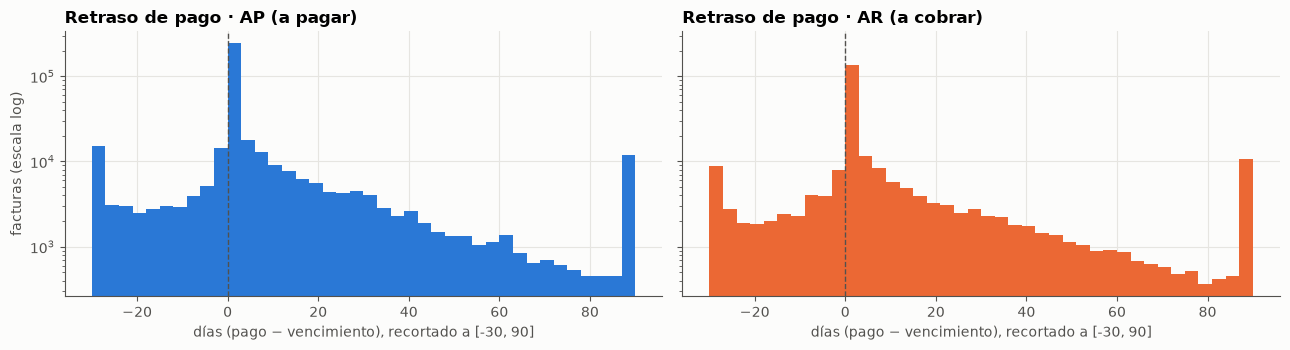

In [31]:
paid = inv[inv.status == "paid"].copy()
paid["plazo"] = (paid.due_date - paid.issuance_date).dt.days
paid["retraso"] = (paid.payment_date - paid.due_date).dt.days

display(paid.groupby("dir")[["plazo", "retraso"]].describe(percentiles=[.25, .5, .75, .9]).T.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, (lab, g), c in zip(axes, paid.groupby("dir"), PAL):
    ax.hist(g.retraso.clip(-30, 90), bins=np.arange(-30, 93, 3), color=c)
    ax.axvline(0, color=INK2, lw=1, ls="--")
    ax.set_yscale("log"); ax.set_title(f"Retraso de pago · {lab}")
    ax.set_xlabel("días (pago − vencimiento), recortado a [-30, 90]")
axes[0].set_ylabel("facturas (escala log)")
plt.tight_layout(); plt.show()

- La mayoría de las facturas se paga justo al vencimiento (retraso 0), pero hay una cola larga de retrasos.
- **Retraso AP** (lo que la empresa tarda en pagar a sus proveedores): **cuando se alarga, suele indicar tensión de caja**. Es la señal clásica.
- **Retraso AR** (lo que tardan sus clientes en pagarle): si sube, se deteriora el circulante.
- Hay fechas absurdas (`due_date` en el año 7025). **Recortad** plazos y retrasos, por ejemplo a [-60, 365].

### 8.3 · ¿`overdue` es impago real o higiene del ERP?

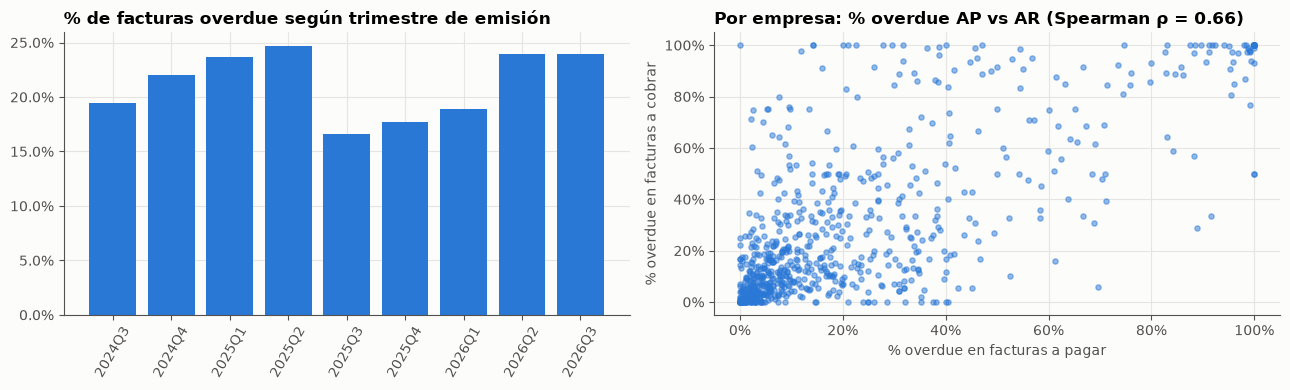

In [32]:
por_q = inv.groupby(inv.issuance_date.dt.to_period("Q")).status.apply(lambda s: (s == "overdue").mean())
emp_ovd = inv.assign(ovd=inv.status == "overdue").groupby(["company_id", "dir"]).ovd.mean().unstack().dropna()
rho = emp_ovd.corr("spearman").iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(por_q.index.astype(str), por_q.values, color=PAL[0])
axes[0].set_title("% de facturas overdue según trimestre de emisión")
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1)); axes[0].tick_params(axis="x", rotation=60)
axes[1].scatter(emp_ovd["AP (a pagar)"], emp_ovd["AR (a cobrar)"], s=14, alpha=0.5, color=PAL[0])
axes[1].set_title(f"Por empresa: % overdue AP vs AR (Spearman ρ = {rho:.2f})")
axes[1].set_xlabel("% overdue en facturas a pagar"); axes[1].set_ylabel("% overdue en facturas a cobrar")
for a in (axes[1].xaxis, axes[1].yaxis): a.set_major_formatter(mticker.PercentFormatter(1))
plt.tight_layout(); plt.show()

Dos pistas de que `overdue` refleja sobre todo **cómo cada empresa mantiene su ERP** y no tanto impago real:
1. Incluso las facturas de **2024** siguen overdue en un ~20%. Casi dos años sin cobrar ni pagar sería raro a esa escala.
2. Las empresas con mucho overdue en lo que deben pagar también lo tienen en lo que deben cobrar (ρ≈0,6). Es un rasgo de la empresa, no del flujo.

**Qué implica:** no uséis `% overdue` en valor absoluto como señal de salud. Usad la **desviación respecto a la propia historia de la empresa** ("¿su overdue sube frente a su normal?") y dad prioridad a los retrasos de facturas `paid`.

## 9 · Cruces entre tablas

### 9.1 · Cobertura por fuente de datos

No todas las entidades tienen todas las fuentes. El score **tiene que funcionar con lo que haya**.

In [33]:
fuentes = {
    "transacciones": set(tx.company_id), "facturas": set(invoices.company_id),
    "deuda": set(debt.company_id), "saldos": set(balances.company_id),
    "cuadro amortización": set(schedule.company_id),
}
cob = pd.DataFrame({k: companies.company_id.isin(v) for k, v in fuentes.items()})
cob["group_id"] = companies.group_id
cob_grp = cob.groupby("group_id").any()
pd.DataFrame({"empresas": cob.drop(columns="group_id").sum(), "grupos": cob_grp.sum()})

,empresas,grupos
transacciones,1286,250
facturas,785,167
deuda,378,150
saldos,1273,250
cuadro amortización,40,30


In [34]:
combo = cob_grp[["facturas", "deuda"]].value_counts().rename("grupos").reset_index()
combo.replace({True: "sí", False: "no"})

,facturas,deuda,grupos
0,sí,sí,101
1,sí,no,66
2,no,sí,49
3,no,no,34


### 9.2 · Check de contrapartes: ¿hay red entre empresas?

Es el check que decide entre el Escenario A (grafo de contagio) y el B (ver "Producto" en `CLAUDE.md`). ¿Hay contrapartes compartidas entre empresas o grupos distintos?

In [35]:
for nombre, df in [("transacciones", tx), ("facturas", invoices)]:
    d = df.dropna(subset=["counterparty_id"])
    per = d.assign(g=d.company_id.map(comp2grp)).groupby("counterparty_id").agg(
        empresas=("company_id", "nunique"), grupos=("g", "nunique"))
    print(f"{nombre:14s} contrapartes: {len(per):7,d} | compartidas por >1 empresa: {(per.empresas > 1).sum():4d} "
          f"| por >1 grupo: {(per.grupos > 1).sum():4d}")
print("Descripciones que mencionan un company_id:", tx.description.str.contains("COMP_", regex=False, na=False).sum())

transacciones  contrapartes:  47,796 | compartidas por >1 empresa:   91 | por >1 grupo:   90


facturas       contrapartes: 124,030 | compartidas por >1 empresa:    0 | por >1 grupo:    0


Descripciones que mencionan un company_id: 0


**Resultado: no hay red.** Cada contraparte pertenece prácticamente a una sola empresa: 0 compartidas en facturas y 91 de 47.796 en transacciones. Además, no hay forma de mapear una contraparte a un `company_id` del dataset. **Estamos en el Escenario B:** no hay grafo de contagio ni forma de puntuar a los clientes de una empresa con el score. Lo que sí se puede hacer con las contrapartes es medir la **concentración** (dependencia de los principales clientes y proveedores) y su evolución.

### 9.3 · Reconstrucción del saldo histórico

`balances` solo da el saldo a 2026-09-01, pero con las transacciones se puede ir hacia atrás:

$$\text{saldo}(t) = \text{saldo final} - \sum \text{movimientos posteriores a } t$$

Lo hacemos para las cuentas corrientes (`checking`) en EUR y enmascaramos los meses anteriores al primer movimiento de cada cuenta.

In [36]:
chk = banking[(banking.type == "checking") & (banking.currency == "EUR")].product_id
t = tx[tx.product_id.isin(chk) & (tx.date < "2026-09-02")]
flujo = t.groupby(["product_id", "mes"]).amount.sum().unstack(fill_value=0).sort_index(axis=1)
saldo_final = balances.set_index("product_id").balance.reindex(flujo.index)
flujo = flujo[saldo_final.notna()]; saldo_final = saldo_final.dropna()

# saldo a fin del mes m = saldo_final - flujos de los meses posteriores a m
posteriores = flujo.iloc[:, ::-1].cumsum(axis=1).iloc[:, ::-1].shift(-1, axis=1).fillna(0)
saldo = posteriores.rsub(saldo_final, axis=0)
primer_mes = t.groupby("product_id").mes.min().reindex(saldo.index)
saldo = saldo.where(np.array([[c >= p for c in saldo.columns] for p in primer_mes]))   # sin dato antes del 1er movimiento
saldo = saldo.drop(columns=pd.Period("2026-09", "M"))

neg = (saldo < -1000).any(axis=1)
print(f"Cuentas reconstruidas: {len(saldo):,} | con algún mes < -1.000 €: {pct(neg.mean())}")

saldo_emp = saldo.groupby(banking.set_index("product_id").company_id.reindex(saldo.index)).sum(min_count=1)
print(f"Empresas con serie de liquidez mensual: {len(saldo_emp):,}")

Cuentas reconstruidas: 3,375 | con algún mes < -1.000 €: 11.0%
Empresas con serie de liquidez mensual: 1,158


El **89% de las cuentas nunca baja de -1.000 €**, así que la reconstrucción es coherente. Las que sí bajan probablemente son cuentas con movimientos que faltan, pólizas mal tipadas o outliers. Con esto tenemos una **serie mensual de liquidez por empresa**, seguramente la feature más valiosa del dataset. Por ejemplo, dos empresas que mejoran y dos que empeoran (entre las que tienen una serie limpia):

Empresas con 24 meses: 399 | con serie limpia: 120


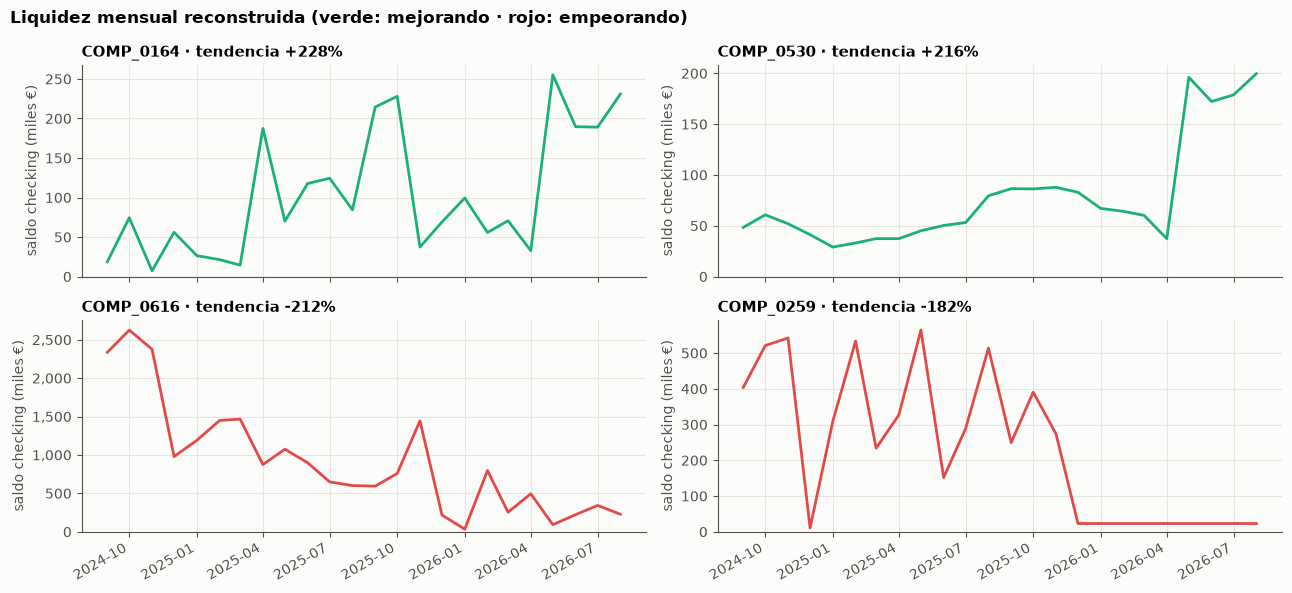

In [37]:
completas = saldo_emp.dropna()                       # empresas con los 24 meses
med = completas.median(axis=1)
# Si se eligen solo por tendencia extrema salen artefactos (saltos de miles de millones por los
# outliers de 7.3). Nos quedamos con series "limpias": sin saldo negativo y sin picos > 4x la mediana
limpias = completas[(completas.min(axis=1) >= 0) & (med > 50_000) & (completas.max(axis=1) < 4 * med)]
tend = (limpias.iloc[:, -6:].median(axis=1) - limpias.iloc[:, :6].median(axis=1)) / med
print(f"Empresas con 24 meses: {len(completas)} | con serie limpia: {len(limpias)}")
ejemplos = list(tend.nlargest(2).index) + list(tend.nsmallest(2).index)

fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)
for ax, emp in zip(axes.flat, ejemplos):
    s = limpias.loc[emp]
    color = PAL[2] if tend[emp] > 0 else PAL[7]
    ax.plot(s.index.to_timestamp(), s.values / 1e3, color=color)
    ax.set_title(f"{emp} · tendencia {tend[emp]:+.0%}", fontsize=11)
    ax.set_ylabel("saldo checking (miles €)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
    ax.set_ylim(0)
fig.suptitle("Liquidez mensual reconstruida (verde: mejorando · rojo: empeorando)", x=0.01, ha="left", fontweight="bold")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

Algunas series acaban **planas**, como COMP_0259 desde 2025-12: la cuenta deja de tener movimientos. Puede ser un cese de actividad, una desconexión del banco o que la empresa haya movido su operativa a otra cuenta. ¿Cuántas empresas dejan de tener transacciones antes del final?

In [38]:
ultima = txm.groupby("company_id").date.max()
print(f"Empresas cuya última transacción es anterior a 2026-08: {(ultima < '2026-08-01').sum()} "
      f"| anterior a 2026-03: {(ultima < '2026-03-01').sum()}")
ultima[ultima < "2026-08-01"].dt.to_period("Q").value_counts().sort_index().to_frame("empresas").T

Empresas cuya última transacción es anterior a 2026-08: 123 | anterior a 2026-03: 34


date,2025Q2,2025Q3,2025Q4,2026Q1,2026Q2,2026Q3
empresas,6,5,13,15,39,45


**Qué implica:** "dejar de tener datos" puede ser una señal en sí misma (o un evento para el target), pero también puede ser una baja en Embat que no tiene nada que ver con la salud. Hay que decidir cómo tratarlo y **confirmarlo con Embat**, porque el score de esas empresas en sus últimos meses depende de ello.

## 10 · Conclusiones para el feature engineering

### Lo que hay (y lo que no)
- **No hay columna target.** El score lo define el script del leaderboard; si no trae etiquetas, hay que construirlas a partir de eventos observables (sección 7.4).
- **Unidad probable: el grupo** (250). Split de validación **por `group_id`**.
- **Transacciones: 100% de cobertura. Facturas: 61% de las empresas. Deuda: 29%.** El score debe funcionar solo con transacciones y usar el resto cuando esté.
- **No hay red de contrapartes:** estamos en el Escenario B.

### Trampas que hay que tratar sí o sí
| trampa | tratamiento |
|---|---|
| Onboarding escalonado (solo 86 grupos con 24 meses) | enmascarar los meses anteriores a la 1ª transacción; features relativas, no volúmenes absolutos |
| 2026-09 tiene 1 día | excluir |
| Importes enormes en moneda local | no eliminar por importe; convertir a EUR y comparar ahí (D32) |
| 28 monedas (44 con cuentas y facturas) | tipo fijo por moneda a EUR (`xray.fx`); futuro: tipos diarios |
| `status` de factura = foto final | reconstruir las facturas abiertas en cada mes (`facturas_abiertas`) |
| `payment_date` de relleno en impagadas | usar solo si `status == "paid"` |
| `overdue` ≈ higiene del ERP | medir la desviación respecto a la propia empresa |
| Estacionalidad (agosto, febrero) | comparar interanual o desestacionalizar |
| `transactions.csv` con NUL | `load_transactions()` |

### Features candidatas (empresa/grupo × mes)
**Nivel**
- Liquidez reconstruida y **meses de cobertura** = saldo / gastos fijos mensuales (`salary` + `social_security` + `tax` + `utility`)
- Ratio entradas/salidas operativas y margen de caja
- Retraso medio de pago a proveedores (DPO) y de cobro de clientes (DSO)
- Uso de la póliza de crédito y peso del coste de la deuda (`debt_repayment` + `interest_charge`) sobre las entradas
- Concentración de clientes y proveedores (top-3 de contrapartes)

**Dinámica** (sobre las anteriores)
- Deltas y pendientes a 3 y 6 meses, aceleración
- Volatilidad de los flujos
- z-score contra la propia historia de la empresa
- Comparación con el mismo mes del año anterior

**Eventos** (conteos en ventanas móviles; cuidado si también forman parte del target)
- `EMBARGO`, `IMPAGADO`, `APLAZAMIENTO`, `DESCUBIERTO`, recibos devueltos (`collection_refund`)